# Prodigy InfoTech — Data Science Internship
## Task 02: Data Cleaning and Exploratory Data Analysis (EDA)

**Objective:** Perform data cleaning and exploratory data analysis on a dataset, explore relationships between variables, and identify patterns and trends.

This project uses the Titanic dataset, a common beginner-friendly dataset for EDA.

## 1. Import Libraries


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Dataset

The Titanic dataset is loaded from the Seaborn public dataset repository.

In [6]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(url)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Understand the Dataset

In [7]:
print('Column names:')
print(df.columns.tolist())

print('\nData types and non-null values:')
df.info()

print('\nDescriptive statistics:')
display(df.describe(include='all').T)

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types and non-null values:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Check and Clean Missing Values

We identify missing values and fill numeric/categorical columns using simple, transparent rules.

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
print('Missing values before cleaning:')
display(missing[missing > 0])

# Fill missing age values with the median.
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing embarked values with the most frequent category.
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Fill missing embark_town values with the most frequent category.
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

# Drop the 'deck' column because it contains a large amount of missing data.
df = df.drop(columns=['deck'])

print('Missing values after cleaning:')
display(df.isnull().sum().sort_values(ascending=False).head())

Missing values before cleaning:


deck           688
age            177
embarked         2
embark_town      2
dtype: int64

Missing values after cleaning:


survived    0
pclass      0
sex         0
age         0
sibsp       0
dtype: int64

## 5. Explore Survival by Gender

Survival rate by gender:


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

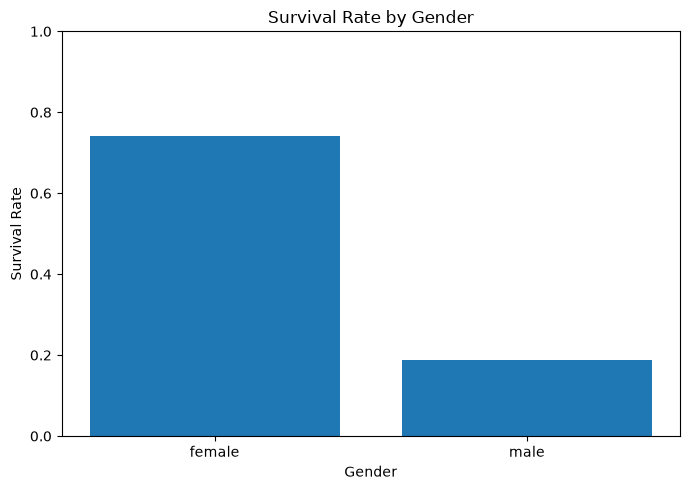

In [9]:
gender_survival = df.groupby('sex')['survived'].mean().sort_values(ascending=False)

print('Survival rate by gender:')
display(gender_survival)

plt.figure(figsize=(7,5))
plt.bar(gender_survival.index, gender_survival.values)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. Explore Survival by Passenger Class

Survival rate by passenger class:


pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

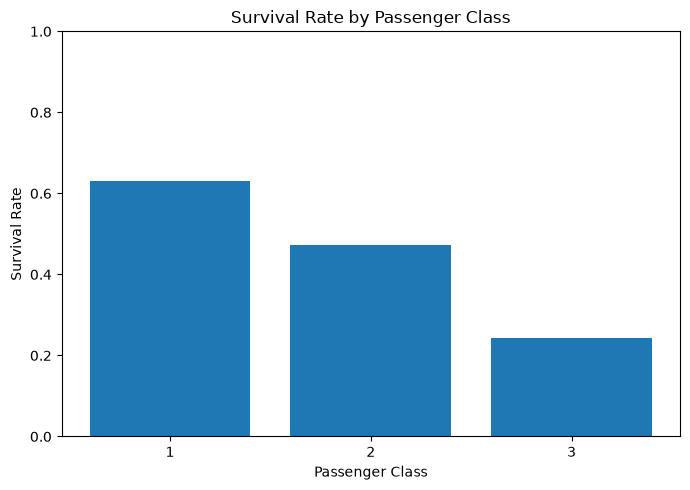

In [10]:
class_survival = df.groupby('pclass')['survived'].mean()

print('Survival rate by passenger class:')
display(class_survival)

plt.figure(figsize=(7,5))
plt.bar(class_survival.index.astype(str), class_survival.values)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Age Distribution

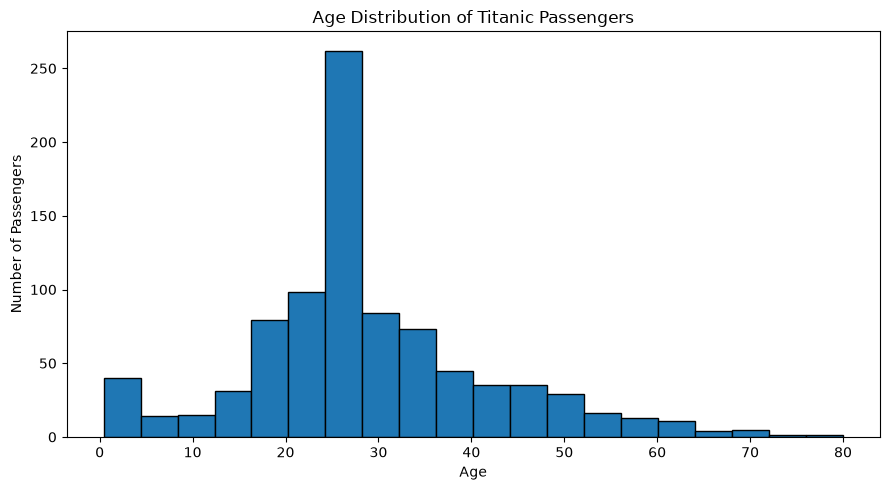

In [11]:
plt.figure(figsize=(9,5))
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

## 8. Fare and Survival

Average fare by survival outcome:


survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

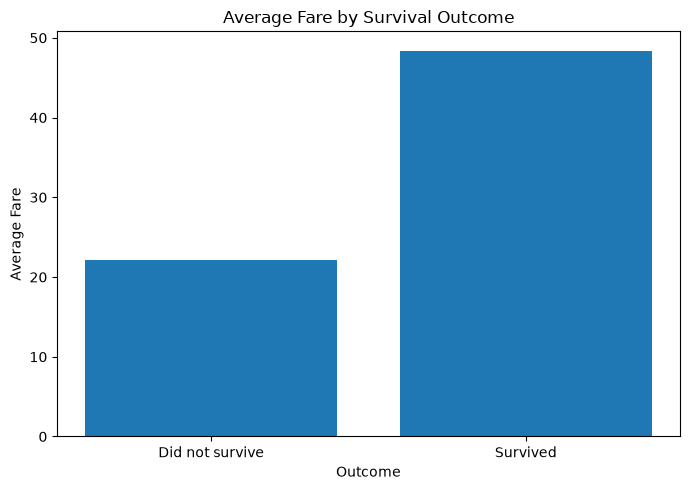

In [12]:
fare_survival = df.groupby('survived')['fare'].mean()
print('Average fare by survival outcome:')
display(fare_survival)

plt.figure(figsize=(7,5))
plt.bar(['Did not survive', 'Survived'], fare_survival.values)
plt.title('Average Fare by Survival Outcome')
plt.xlabel('Outcome')
plt.ylabel('Average Fare')
plt.tight_layout()
plt.show()

## 9. Key Findings

- Survival rates differ substantially by gender.
- Passenger class is associated with survival: higher-class passengers generally had higher survival rates.
- Passenger ages are concentrated in younger and middle-adult ranges, with fewer very old passengers.
- Average fare differs between passengers who survived and those who did not.

### Conclusion
The EDA shows that passenger characteristics such as gender and passenger class are strongly associated with survival in the Titanic dataset. Data cleaning was necessary for missing age and embarkation information. Visualizations make these relationships easier to identify and communicate.